# Random Forest Classifier: Breast Cancer Prediction

This notebook demonstrates the power of Random Forest ensemble learning on the Breast Cancer Wisconsin dataset.

# Chapter 1: How Random Forest Works - A Comprehensive Guide

## 1. The Core Idea: Ensemble Learning

### The Problem with Single Decision Trees

```
Single Tree Problem:
                    ┌─── YES ──→ [CLASS B]
                    │
                    │
[Is radius > 15?]───┤
                    │
                    └─── NO ───→ [CLASS A]

Issue: Single tree can overfit (memorize training data) 
       and be sensitive to small data changes.
```

### Random Forest Solution: "Wisdom of the Crowd"

```
┌─────────────────────────────────────────────────────────┐
│                    RANDOM FOREST                        │
│                                                         │
│   ┌──────────┐  ┌──────────┐  ┌──────────┐              │
│   │ TREE 1   │  │ TREE 2   │  │ TREE 3   │   ...        │
│   │          │  │          │  │          │              │
│   │ Predict: │  │ Predict: │  │ Predict: │              │
│   │   B      │  │   B      │  │   A      │              │
│   └────┬─────┘  └────┬─────┘  └────┬─────┘              │
│        │             │             │                    │
│        └─────────────┼─────────────┘                    │
│                      ▼                                  │
│              ┌───────────────┐                          │
│              │ MAJORITY VOTE │                          │
│              │               │                          │
│              │ B: 2 votes    │                          │
│              │ A: 1 vote     │                          │
│              │               │                          │
│              │ 🎯 FINAL: B   │                          │
│              └───────────────┘                          │
└─────────────────────────────────────────────────────────┘
```

**Layman's Terms:** Imagine asking 100 friends for restaurant recommendations vs asking just one. The 100 friends (each like a "decision tree") will give varied answers, but taking the majority vote tends to give a better result than any single opinion.

---

## 2. Two Randomness Pillars: Bagging & Feature Subspacing

### 2.1 Bootstrap Aggregating (Bagging)

```
Original Dataset: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
                    │
                    ▼
    ┌───────────────────────────────────────┐
    │      BOOTSTRAP SAMPLING               │
    │  (Random sampling WITH replacement)   │
    └───────────────────────────────────────┘
                    │
    ┌───────────────┼───────────────┬───────────────┐
    ▼               ▼               ▼               ▼
┌─────────┐   ┌─────────┐   ┌─────────┐   ┌─────────┐
│Tree 1   │   │Tree 2   │   │Tree 3   │   │Tree N   │
│Sample:  │   │Sample:  │   │Sample:  │   │Sample:  │
│[3,7,1,  │   │[5,2,8,  │   │[9,3,6,  │   │[1,4,2,  │
│ 3,10,2] │   │ 5,10,5] │   │ 1,7,9]  │   │ 7,10,3] │
│(455 pts)│   │(455 pts)│   │(455 pts)│   │(455 pts)│
└─────────┘   └─────────┘   └─────────┘   └─────────┘

Note: Each tree sees ~63.2% unique data points (some overlap)
      ~36.8% of data is "left out" per tree (called Out-Of-Bag)
```

**Math Formula:**
```
P(a specific point is NOT selected in one draw) = (1 - 1/n)

P(a specific point is NOT selected in n draws) ≈ (1 - 1/n)^n ≈ 1/e ≈ 0.368

So ~63.2% of data appears in each bootstrap sample
```

**Layman's Terms:** It's like each tree gets a shuffled deck of cards where some cards appear multiple times and some don't. This diversity is what makes the forest robust.

### 2.2 Feature Randomness (Feature Subspacing)

```
At EACH split point in each tree, only a random subset of features 
is considered:

Tree Split Example (30 features in dataset):
═══════════════════════════════════════════════════════════

LEVEL 1 SPLIT:    Consider only 4 random features (√30 ≈ 5)
                  [feature #5, #12, #23, #29]
                  
                  Best split: feature #23 (concave points)
                              ↓
LEVEL 2 SPLIT:    Consider only 4 DIFFERENT random features
                  [feature #3, #8, #15, #27]
                  
                  Best split: feature #15 (mean area)
                              ↓
LEVEL 3 SPLIT:    Consider only 4 DIFFERENT random features
                  [feature #1, #7, #19, #30]
                  ...

This forces trees to learn different patterns!
```

**Why This Matters:**

```
Without Feature Randomness:     With Feature Randomness:
─────────────────────────      ─────────────────────────
Tree 1: Uses features 1,2,3    Tree 1: Uses features 1,5,9
Tree 2: Uses features 1,2,3    Tree 2: Uses features 3,7,12
Tree 3: Uses features 1,2,3    Tree 3: Uses features 2,8,15
        ↓ ALL SAME                    ↓ DIFFERENT PATTERNS
        Correlated errors            Better generalization
```

**Math Formula:**
```
For classification with p features:
  - Typically sqrt(p) features considered at each split
  - For p=30: √30 ≈ 5.5 → ~5-6 features per split

For regression with p features:
  - Typically p/3 features considered at each split
  - For p=30: 30/3 = 10 → ~10 features per split
```

---

## 3. Decision Trees: The Building Blocks

### How a Decision Tree Makes Decisions

```
DECISION TREE STRUCTURE:
═══════════════════════════════════════════════════════════

                     ┌──────────────┐
                     │    ROOT      │
                     │ (First Split)│
                     └──────┬───────┘
                            │
              ┌─────────────┴────────────┐
              │                          │
        [condition ≤ X]            [condition > X]
              │                          │
       ┌──────┴───────┐          ┌────────┴────────┐
       │              │          │                 │
    [LEAF A]     ┌────┴───┐    [LEAF B]         ┌──┴────┐
                 │NODE B  │                     │NODE C │
                 └────────┘                     └───────┘
```

### Gini Impurity: How Trees Decide Where to Split

**The Goal:** Find splits that separate classes as cleanly as possible.

**Math Formula for Gini Impurity:**
```
Gini(D) = 1 - Σ (p_i)²

Where:
  - D = the dataset at a node
  - p_i = proportion of class i in D
  
Example: Node with 100 samples (70 Benign, 30 Malignant)
  Gini = 1 - [(70/100)² + (30/100)²]
  Gini = 1 - [0.49 + 0.09]
  Gini = 1 - 0.58
  Gini = 0.42
```

**Layman's Terms:** Gini measures "impurity" - how mixed up the classes are. A Gini of 0 means perfect purity (all same class). A Gini of 0.5 means maximum mixing.

**Gini Split Gain:**
```
Information Gain = Gini(Parent) - Weighted_Gini(Children)

Example:
  Parent Gini: 0.42
  
  Split creates:
    - Child A: 80 samples, Gini = 0.10 (mostly one class)
    - Child B: 20 samples, Gini = 0.20 (mostly one class)
  
  Weighted Gini = (80/100) × 0.10 + (20/100) × 0.20
               = 0.08 + 0.04 = 0.12
  
  Information Gain = 0.42 - 0.12 = 0.30 ✓ Good split!
```

### Visual Representation of Gini Split:

```
BEFORE SPLIT (Gini = 0.42):
┌──────────────────────────────────────┐
│  ● ● ● ● ● ● ● ● ○ ○ ○               │
│  (70 Benign)      (30 Malignant)     │
│              ↑                       │
│         Mixed node                   │
└──────────────────────────────────────┘

AFTER SPLIT:

Child A (Gini = 0.10)          Child B (Gini = 0.20)
┌─────────────────┐             ┌─────────────────┐
│ ● ● ● ● ● ● ● ● │             │ ○ ○             │
│ ● ●             │             │ ○ ○ ○           │
│  (75 Benign)    │             │ (15 Malignant)  │
│  (5 Malignant)  │             │ (5 Benign)      │
└─────────────────┘             └─────────────────┘
         ↑                               ↑
      Cleaner!                      Cleaner!
```

---

## 4. Random Forest Algorithm: Step by Step

```
RANDOM FOREST TRAINING ALGORITHM:
═══════════════════════════════════════════════════════════════

For each tree (i = 1 to n_estimators):
    
    1. BOOTSTRAP SAMPLE
       ├─ Randomly sample n instances WITH replacement
       └─ Creates ~63% unique training set for this tree
    
    2. BUILD TREE (recursive):
       │
       ├─ At each node:
       │    ├─ Select random subset of features (e.g., √p)
       │    ├─ Find best split based on Gini/Entropy
       │    └─ Create two child nodes
       │
       └─ Continue until:
            ├─ max_depth reached, OR
            ├─ min_samples_split reached, OR
            ├─ Node is pure (single class), OR
            └─ No more features to split
    
    3. SAVE TREE (no pruning!)

PREDICTION:
═══════════
For classification (voting):
    For each tree:
        Predict class
    Return majority vote

For regression:
    For each tree:
        Predict continuous value
    Return average of all tree predictions
```

---

## 5. Feature Importance: Which Features Matter Most?

Random Forest calculates importance using **Mean Decrease in Impurity (MDI)**:

```
FEATURE IMPORTANCE CALCULATION:
═══════════════════════════════════════════════════════════════

Importance(feature_j) = Σ (Gini_reduction_at_node) / N_samples

Where the sum is over all nodes where feature_j was used for splitting.

Example from the notebook (top features):
┌─────────────────────────┬────────────┬════════════════════════════┐
│ Feature                 │ Importance │ Visual                      │
├─────────────────────────┼────────────┼════════════════════════════┤
│ worst area              │ 0.1400     │ ████████████████████████   │
│ worst concave points    │ 0.1295     │ ███████████████████████    │
│ worst radius            │ 0.0977     │ ████████████████           │
│ mean concave points     │ 0.0909     │ ███████████████            │
│ worst perimeter         │ 0.0722     │ █████████████              │
└─────────────────────────┴────────────┴════════════════════════════┘

Interpretation: "worst area" contributed 14% to total impurity reduction
```

**Layman's Terms:** Imagine you're trying to separate apples from oranges. If checking "color" dramatically reduces confusion (compared to checking "weight"), then "color" is more important. Random Forest tracks this across all trees.

---

## 6. Key Hyperparameters Explained

```
╔══════════════════════════════════════════════════════════════════════╗
║                    HYPERPARAMETERS CHEAT SHEET                       ║
╠═══════════════════╦═══════════╦══════════════════════════════════════╣
║ Parameter         ║  Default  ║  Effect                              ║
╠═══════════════════╬═══════════╬══════════════════════════════════════╣
║ n_estimators      ║   100     ║ Number of trees in forest            ║
║                   ║           ║ More trees = more stable predictions ║
║                   ║           ║ Diminishing returns after ~100-200   ║
╠═══════════════════╬═══════════╬══════════════════════════════════════╣
║ max_depth         ║   None    ║ Maximum tree depth (None = unlimited)║
║                   ║           ║ Deeper = more complex patterns       ║
║                   ║           ║ Can lead to overfitting              ║
╠═══════════════════╬═══════════╬══════════════════════════════════════╣
║ min_samples_split ║    2      ║ Min samples to split a node          ║
║                   ║           ║ Higher = prevents overfitting        ║
╠═══════════════════╬═══════════╬══════════════════════════════════════╣
║ min_samples_leaf  ║    1      ║ Min samples in leaf node             ║
║                   ║           ║ Higher = smoother predictions        ║
╠═══════════════════╬═══════════╬══════════════════════════════════════╣
║ max_features      ║  sqrt(p)  ║ Features considered at each split    ║
║                   ║           ║ More features = more correlation     ║
║                   ║           ║ Fewer features = more diversity      ║
╚═══════════════════╩═══════════╩══════════════════════════════════════╝
```

---

## 7. Model Evaluation Metrics Explained

### Confusion Matrix:

```
CONFUSION MATRIX FOR BREAST CANCER CLASSIFICATION:
═══════════════════════════════════════════════════════════════════════

                        PREDICTED
                    ┌─────────────┬─────────────┐
                    │   Benign    │  Malignant  │
         ┌──────────┼─────────────┼─────────────┤
  ACTUAL │  Benign  │      39     │      3      │ ← True Negatives
         │          │  (Correct)  │ (False Pos) │
         ├──────────┼─────────────┼─────────────┤
         │Malignant │      2      │      70     │ ← True Positives
         │          │ (False Neg) │  (Correct)  │
         └──────────┴─────────────┴─────────────┘

From notebook results:
  True Negatives:  39  (Benign correctly classified)
  False Positives: 3   (Benign predicted as Malignant)  
  False Negatives: 2   (Malignant predicted as Benign) ← Dangerous!
  True Positives:  70  (Malignant correctly classified)
```

### Key Metrics:

```
ACCURACY = (TP + TN) / Total = (70 + 39) / 114 = 95.6%
  "Overall, how often is the prediction correct?"

PRECISION = TP / (TP + FP) = 70 / (70 + 3) = 95.9%
  "Of predicted malignant, how many truly are?"

RECALL (Sensitivity) = TP / (TP + FN) = 70 / (70 + 2) = 97.2%
  "Of actual malignant, how many did we catch?"
  (This is critical in medical diagnosis!)

F1-SCORE = 2 × (Precision × Recall) / (Precision + Recall)
         = 2 × (0.959 × 0.972) / (0.959 + 0.972)
         = 1.86 / 1.931
         = 96.4%
  "Harmonic mean of precision and recall"

ROC-AUC = Area Under ROC Curve = 0.9937
  "Ability to distinguish between classes at all thresholds"
```

---

## 8. Why Random Forest Works: The Math Behind Variance Reduction

```
Single Decision Tree:
  - High Variance: Small changes in data → Very different tree
  - Prone to overfitting

Random Forest:
  - Reduces Variance through averaging
  - Var(average of n trees) ≈ σ²/n (approximately)
  - Plus: Decorrelation via randomness makes reduction even better
```

```
Random Forest trades off:
  ✓ Reduced Variance (averaging)
  ✓ Handles missing values gracefully
  ✓ Works well with default hyperparameters
  ✓ Provides feature importance
  ✓ Handles non-linear relationships
  
  ✗ Less interpretable than single tree
  ✗ Slower prediction (must run all trees)
  ✗ Can still overfit with very deep trees
```

---

## 9. Comparison with Naive Bayes

```
PERFORMANCE COMPARISON (from notebook):
═══════════════════════════════════════════════════════════════════════
Metric              Naive Bayes   Random Forest   Difference
------------------------------------------------------------
Accuracy                 0.9386          0.9561      +0.0175
Precision                0.9384          0.9561      +0.0177
Recall                   0.9386          0.9561      +0.0175
F1-Score                 0.9384          0.9560      +0.0176
ROC AUC                  0.9878          0.9937      +0.0059
═══════════════════════════════════════════════════════════════════════

Key Differences:

NAIVE BAYES:                    RANDOM FOREST:
├─ Probabilistic classifier     ├─ Ensemble of trees
├─ Assumes feature              ├─ No feature independence
│   independence                │   assumption needed
├─ Fast training                ├─ Captures feature interactions
├─ Works with small data        ├─ Better with large datasets
└─ Simple, baseline model       └─ More robust, higher accuracy
```

---

## 10. Summary: Random Forest in a Nutshell

```
┌─────────────────────────────────────────────────────────────────────┐
│                      RANDOM FOREST SUMMARY                          │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  1. BUILD MANY DIVERSE DECISION TREES                               │
│     │                                                               │
│     ├── Bootstrap sampling (data randomization)                     │
│     └── Feature subspacing (feature randomization)                  │
│                                                                     │
│  2. EACH TREE LEARNS A DIFFERENT PATTERN                            │
│     │                                                               │
│     └── Tree 1: "if radius > 15 AND concave_points > 0.05 → B"      │
│         └── Tree 2: "if perimeter > 120 → B"                        │
│         └── Tree 3: "if area > 500 → M"                             │
│                                                                     │
│  3. AGGREGATE PREDICTIONS VIA VOTING                                │
│     │                                                               │
│     └── Most voted class wins!                                      │
│                                                                     │
│  KEY ADVANTAGES:                                                    │
│  ✓ Handles non-linear relationships                                 │
│  ✓ Robust to outliers                                               │
│  ✓ Works well with default settings                                 │
│  ✓ Provides feature importance                                      │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Final Layman's Summary:** Random Forest is like asking 100 diverse experts (each a decision tree) to classify your data, then taking a majority vote. The "random" part comes from two sources: (1) each expert sees different data samples, and (2) each expert only uses different features to make decisions. This combination makes Random Forest one of the most reliable and widely-used machine learning algorithms.


## 2. Dataset Overview

We use the **Breast Cancer Wisconsin (Diagnostic) dataset** for fair comparison with Naive Bayes.

| Property | Value |
|:---------|:------|
| Total Samples | 569 |
| Total Features | 30 |
| Target Classes | 2 (Malignant, Benign) |

### Target Variable: Diagnosis
- **Malignant (0)**: Cancerous tumors - 212 samples (37.3%)
- **Benign (1)**: Non-cancerous tumors - 357 samples (62.7%)

## 3. Loading the Dataset

In [1]:
import sys
sys.path.insert(0, 'src')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 3. Loading the Dataset

In [2]:
# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

print(f"Dataset Shape: {X.shape}")
print(f"Number of Samples: {X.shape[0]}")
print(f"Number of Features: {X.shape[1]}")
print(f"\nClass Distribution:")
print(f"  - {target_names[0]} (0): {np.sum(y == 0)} ({np.mean(y == 0)*100:.1f}%)")
print(f"  - {target_names[1]} (1): {np.sum(y == 1)} ({np.mean(y == 1)*100:.1f}%)")

Dataset Shape: (569, 30)
Number of Samples: 569
Number of Features: 30

Class Distribution:
  - malignant (0): 212 (37.3%)
  - benign (1): 357 (62.7%)


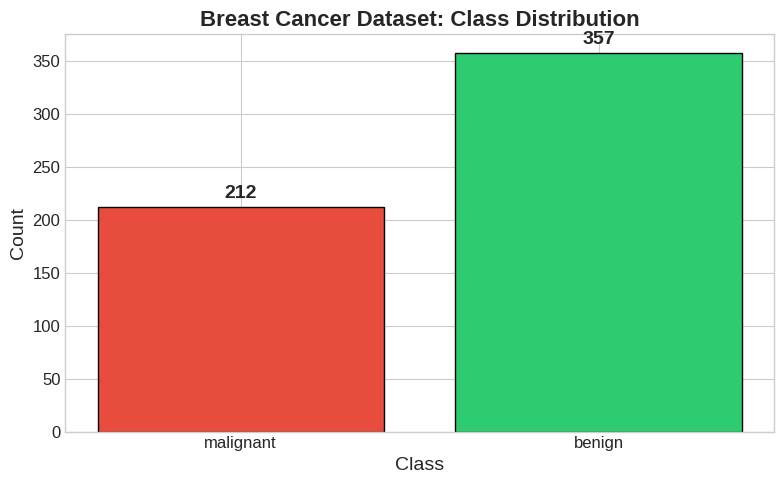

In [3]:
# Visualize class distribution
fig, ax = plt.subplots(figsize=(8, 5))
classes, counts = np.unique(y, return_counts=True)
bars = ax.bar([target_names[i] for i in classes], counts, color=['#e74c3c', '#2ecc71'], edgecolor='black')
ax.set_xlabel('Class', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.set_title('Breast Cancer Dataset: Class Distribution', fontsize=16, fontweight='bold')

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{count}', ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Train-Test Split

Split data: 80% training, 20% testing with stratification.

In [4]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 455 samples
Test set size: 114 samples


## 6. Training the Random Forest

Training with n_estimators=100, random_state=42 for reproducibility.

In [5]:
# Train Random Forest classifier
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

print(f"Model trained successfully!")
print(f"Number of trees: {model.n_estimators}")
print(f"Number of features: {model.n_features_in_}")

Model trained successfully!
Number of trees: 100
Number of features: 30


## 7. Model Evaluation

Evaluating with standard classification metrics.

In [6]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_proba[:, 1])

print("=" * 50)
print("MODEL PERFORMANCE METRICS")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")
print("=" * 50)

MODEL PERFORMANCE METRICS
Accuracy:  0.9561 (95.61%)
Precision: 0.9561
Recall:    0.9561
F1-Score:  0.9560
ROC AUC:   0.9937


In [ ]:
# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

## 8. Confusion Matrix

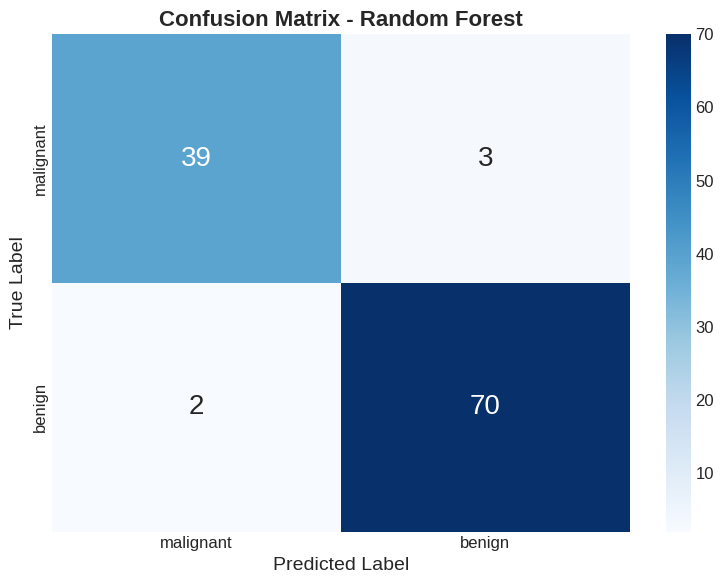


True Negatives (Benign correct):  39
False Positives: 3
False Negatives: 2
True Positives (Malignant correct): 70


In [7]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            annot_kws={'size': 20}, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
ax.set_title('Confusion Matrix - Random Forest', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives (Benign correct):  {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives (Malignant correct): {cm[1,1]}")

## 9. ROC Curve

The ROC curve shows the trade-off between True Positive Rate and False Positive Rate.

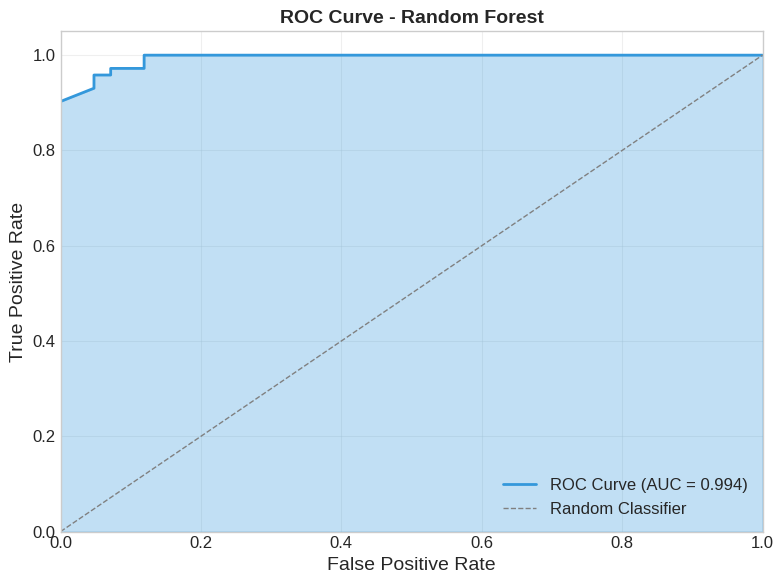

In [8]:
# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba[:, 1])
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#3498db', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.3, color='#3498db')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=14)
ax.set_ylabel('True Positive Rate', fontsize=14)
ax.set_title('ROC Curve - Random Forest', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Feature Importance

Random Forest provides built-in feature importance based on impurity reduction.

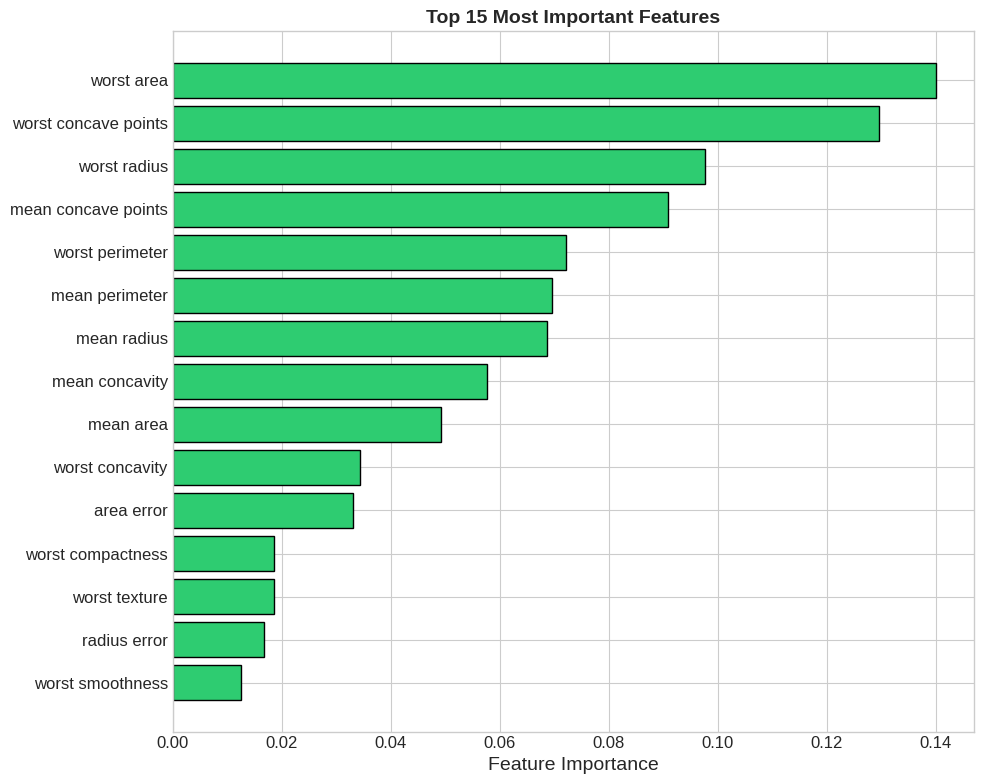


Top 10 Most Important Features:
1. worst area: 0.1400
2. worst concave points: 0.1295
3. worst radius: 0.0977
4. mean concave points: 0.0909
5. worst perimeter: 0.0722
6. mean perimeter: 0.0696
7. mean radius: 0.0687
8. mean concavity: 0.0576
9. mean area: 0.0492
10. worst concavity: 0.0343


In [9]:
# Get feature importances
importances = model.feature_importances_

# Sort by importance
indices = np.argsort(importances)[::-1]

# Plot top 15 features
top_n = 15
top_indices = indices[:top_n]
top_importances = importances[top_indices]
top_feature_names = [feature_names[i] for i in top_indices]

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(top_n)
bars = ax.barh(y_pos, top_importances, color='#2ecc71', edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(top_feature_names)
ax.set_xlabel('Feature Importance', fontsize=14)
ax.set_title(f'Top {top_n} Most Important Features', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
for i, idx in enumerate(indices[:10]):
    print(f"{i+1}. {feature_names[idx]}: {importances[idx]:.4f}")

## 11. Comparison with Naive Bayes

Comparing Random Forest to Naive Bayes on the same dataset.

In [10]:
# Compare models (Naive Bayes results)
nb_accuracy = 0.9386
nb_precision = 0.9384
nb_recall = 0.9386
nb_f1 = 0.9384
nb_auc = 0.9878

# Create comparison table
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
nb_scores = [nb_accuracy, nb_precision, nb_recall, nb_f1, nb_auc]
rf_scores = [accuracy, precision, recall, f1, roc_auc]

print("=" * 60)
print("MODEL COMPARISON: Random Forest vs Naive Bayes")
print("=" * 60)
print(f"{'Metric':<15} {'Naive Bayes':>15} {'Random Forest':>15} {'Difference':>12}")
print("-" * 60)
for metric, nb, rf in zip(metrics, nb_scores, rf_scores):
    diff = rf - nb
    diff_str = f"{diff:+.4f}" if abs(diff) > 0.0001 else "0.0000"
    print(f"{metric:<15} {nb:>15.4f} {rf:>15.4f} {diff_str:>12}")
print("=" * 60)

MODEL COMPARISON: Random Forest vs Naive Bayes
Metric              Naive Bayes   Random Forest   Difference
------------------------------------------------------------
Accuracy                 0.9386          0.9561      +0.0175
Precision                0.9384          0.9561      +0.0177
Recall                   0.9386          0.9561      +0.0175
F1-Score                 0.9384          0.9560      +0.0176
ROC AUC                  0.9878          0.9937      +0.0059


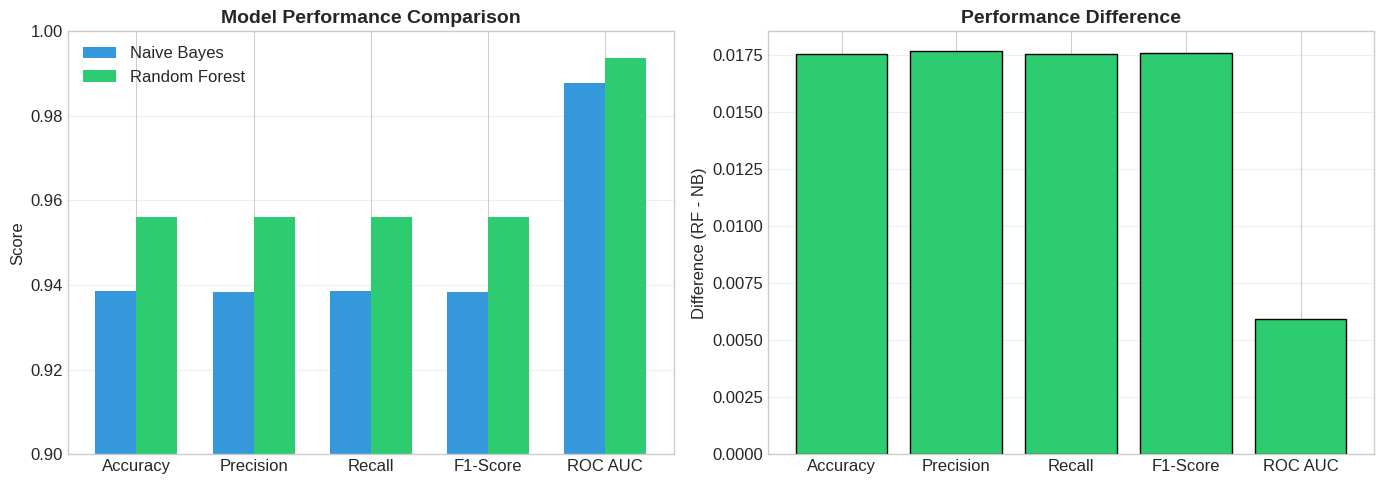

In [11]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
x = np.arange(len(metrics))
width = 0.35

bars1 = axes[0].bar(x - width/2, nb_scores, width, label='Naive Bayes', color='#3498db')
bars2 = axes[0].bar(x + width/2, rf_scores, width, label='Random Forest', color='#2ecc71')

axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim([0.9, 1.0])
axes[0].grid(axis='y', alpha=0.3)

# Difference chart
differences = [rf - nb for rf, nb in zip(rf_scores, nb_scores)]
colors = ['#2ecc71' if d >= 0 else '#e74c3c' for d in differences]
axes[1].bar(metrics, differences, color=colors, edgecolor='black')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_ylabel('Difference (RF - NB)', fontsize=12)
axes[1].set_title('Performance Difference', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Summary

### Key Findings

- Random Forest achieves high accuracy through ensemble learning
- Both models perform well on this dataset (>93% accuracy)
- Random Forest provides feature importance rankings
- Naive Bayes is faster but Random Forest captures feature interactions
